In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### 도구 정의

In [2]:
# Tavily Search 도구 생성 및 검색
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프의 노드와 엣지가 뭐야?')

{'query': '랭그래프의 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체, 클래스 형태로 정의할 수 있다.\n\n 특징\n  + 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n  + 입력과 출력은 State를 기반으로 한다.\n  + 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 노드 만들기\n\n입력\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] ### 2.1. 엣지 개념\n\n엣지는 노드와 노드를 연결하는 경로다. 데이터가 한 노드에서 다음 노드로 흘러가는 길이라고 보면 된다.  \n   \n특징\n\n 엣지는 시작 노드와 도착 노드를 지정해야 한다.\n 조건부 엣지를 설정해 흐름을 분기시킬 수 있다.\n 한 노드에서 여러 노드로 데이터를 보낼 수도 있다.\n\n### 2.2. 엣지 만드는 방법\n\n#### 2.2.1. 일반 edge\n

### 그래프 구성

In [3]:
from typing import TypedDict, Annotated, List # 타입 힌트 도구
from langgraph.graph.message import add_messages # 메세지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage # 메세지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages : Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 파인딩

# State의 messages를 입력 받아, 응답 메세지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages']) # 누적된 메세지 리스트로 LLM 호출
    return {'messages' : [response]} # add_messages 규칙에 의해 기존 messages에 응답이 누적됨


In [4]:
from langchain_core.messages import ToolMessage # 툴 실행 결과를 담을 메세지 타입
import json # json 문자열 파싱 도구

# tool call을 실행하는 노드 클래스 
class ToolNode:
    def __init__(self, tools):
        self.tools_by_name = {tool.name : tool for tool in tools} # {tool_name : tool 객체}

    def __call__(self, inputs : State):
        """
        도구 호출을 처리하는 메서드입니다.

        Args:
            inputs (dict): 입력 상태 딕셔너리. 'messages' 키에 메시지 리스트가 포함되어야 합니다.

        Returns:
            dict: 도구 실행 결과를 담은 메시지 리스트가 포함된 딕셔너리.
                 형식: {"messages": [ToolMessage, ...]}

        Raises:
            ValueError: 입력에 메시지가 없는 경우 발생합니다.
        """
        # messages가 있으면 마지막 메세지 가져오고, 아니면 에러 발생
        if messages := inputs.get("messages"):
            message = messages[-1] # 마지막 메세지(AI Message)는 도구 호출 대상
        else:
            raise ValueError('메세지가 없습니다!')

        outputs = [] # ToolMessage 들을 담을 리스트

        # 마지막 메세지(AI Message)에 포함된 tool_calls를 순회
        for tool_call in message.tool_calls:
            # tool 이름을 찾아 실행 (매개변수는 ai메세지에서 전달한 입력매개변수)
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args'])
            tool_message =ToolMessage(
                content= json.dump(tool_result), # 결과를 json으로 파싱
                name = tool_call['name'],
                tool_call_id = tool_call['id']
            )
            outputs.append(tool_message)

        return {"messages" : outputs}

In [5]:
# 도구 호출 여부에 따른 분기 함수 (tools_condition)
# - 다음 분기로 tools로 보낼지 아니면 END로 끝낼지 결정

from pprint import pprint
def tools_condition(state : State):
    pprint(state['messages'])

    if isinstance(state, list): # state가 list형태일 경우 (MessageGraph)
        ai_message = state[-1] # 마지막 message는 AIMessage
    elif messages := state.get('messages', []): # state가 dict 형태(StateGraph)인 경우
        ai_message = messages[-1]
    else:
        raise ValueError(f"State의 tool_edge에서 들어온 메시지 확인 불가: {state}")

    # AIMessage에 tool_calls가 있으면 도구 노드로 이동
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return 'tools'
    # tool_calls가 없으면 END노드로 이동
    return END

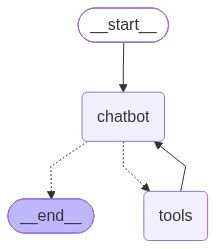

In [6]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot') # START -> chatbot
workflow.add_node('chatbot', chatbot)     # chatbot
workflow.add_node('tools', tool_node)     # tools
workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END:END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile() # 설계된 workflow를 실행 가능한 그래프로 컴파일
graph


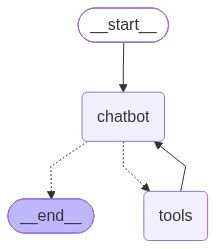

In [7]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
workflow = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot') # START -> chatbot
workflow.add_node('chatbot', chatbot)     # chatbot
workflow.add_node('tools', tool_node)     # tools
workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END:END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile() # 설계된 workflow를 실행 가능한 그래프로 컴파일
graph


In [ ]:
user_query = '랭그래프의 구성요소는?'
state = {'messages': [HumanMessage(content=user_query)]}

response = graph.invoke(state) # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='랭그래프의 구성요소는?', additional_kwargs={}, response_metadata={}, id='06d88efe-5461-4e2c-aada-32dc0d8e2f2b'),
              AIMessage(content='랭그래프(LangGraph)의 주요 구성요소는 보통 다음과 같습니다.\n\n1. **노드(Node)**\n   - 실행되는 작업 단위입니다.\n   - 예: LLM 호출, 툴 실행, 데이터 전처리, 분기 판단 등.\n\n2. **엣지(Edge)**\n   - 노드 간의 이동 경로입니다.\n   - 어떤 노드 다음에 어떤 노드가 실행될지 정의합니다.\n\n3. **그래프(Graph)**\n   - 노드와 엣지를 묶어 전체 실행 흐름을 구성합니다.\n   - 순차 흐름, 분기, 반복, 조건부 라우팅 등을 표현할 수 있습니다.\n\n4. **상태(State)**\n   - 그래프가 실행 중 공유하는 데이터입니다.\n   - 각 노드가 상태를 읽고/수정하면서 작업을 이어갑니다.\n   - LangGraph의 핵심 개념 중 하나입니다.\n\n5. **상태 전이(State transition)**\n   - 노드 실행 후 상태가 어떻게 바뀌는지 정의하는 방식입니다.\n\n6. **체크포인트/메모리(Checkpointing / Memory)**\n   - 실행 중간 상태를 저장해 두었다가 복구할 수 있게 합니다.\n   - 대화형 에이전트나 장기 실행 작업에서 유용합니다.\n\n7. **조건부 엣지(Conditional Edge)**\n   - 상태나 결과에 따라 다음 노드를 동적으로 선택하는 연결입니다.\n   - 예: “검색이 필요하면 tool 노드로, 아니면 종료”.\n\n8. **시작/종료 노드**\n   - 그래프의 진입점과 종료점을 지정합니다.\n\n원하시면 제가 이어서  \n- **LangGraph 구조를 그림처럼 설명**하거나  \n- **LangChain

In [9]:
user_query = '최근 우리나라의 산불 횟수??'
state = {'messages': [HumanMessage(content=user_query)]}

response = graph.invoke(state) # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 우리나라의 산불 횟수??', additional_kwargs={}, response_metadata={}, id='46cb9480-7c10-4dc5-84f8-222aee2e7dcd'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 1278, 'total_tokens': 1333, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJqZucYJu4xgCnEKavpQzfoqpABUZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a064e3-df0e-74d1-994c-f38153f7582f-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '대한민국 최근 산불 발생 횟수 통계 2024 2025 산림청', 'search_de